In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from scipy.stats import norm

import random

In [2]:
# Style bao cao
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "font.family": "sans-serif",
})
ACCENT = "#1f4e79"
SECONDARY = "#c55a11"
RNG = np.random.default_rng(42)

## 1) Xác định chính xác cấu trúc deal

Trước khi định giá, bạn phải chốt toàn bộ term sheet:

- danh mục reference entities
- notional từng tên
- maturity của tranche
- payment dates
- coupon/running spread cố định hay chưa biết
- có upfront hay không
- attachment (A) và detachment (D)
- recovery assumption
- quy tắc settlement khi default
- có front-end protection, accrued premium, hay trigger đặc biệt không

Về mặt cơ học, attachment là ngưỡng bắt đầu ăn lỗ, còn detachment là ngưỡng tranche bị wipe out hoàn toàn; kích thước tranche là (D-A). Trong thực tế, (A,D) thường được quote theo % tổng notional pool. ([U of T Computer Science](https://www.cs.toronto.edu/pub/reports/na/ma-07-phd.pdf))


In [3]:
cds_df = pd.read_csv("cds.csv")
cds_df.set_index("Date", inplace=True)
cds_df.index = pd.to_datetime(cds_df.index)
cds_df1 = cds_df.pivot_table(index="Date", columns="Ticker", values=[f"PX{i}" for i in range(1, 11)])/1e4
cds_df1.columns = [f"{px}_{ticker}" for px, ticker in cds_df1.columns]
cds_df1.head()

,PX1_A,PX1_AALLN,PX1_AAPL,PX1_ABBNVX,PX1_ABBV,PX1_ABC,PX1_ABESM,PX1_ABIBB,PX1_ABT,PX1_ABXCN,...,PX9_WMB,PX9_WMT,PX9_WOORIB,PX9_WPLAU,PX9_WSTP,PX9_WU,PX9_WY,PX9_XL,PX9_XOM,PX9_ZIGGO
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-01,0.001485,0.003283,0.000830,0.000582,NaN,0.000736,0.002628,0.001452,0.000494,0.002526,...,0.029380,0.003520,0.010670,0.015150,0.010960,0.021000,0.008591,0.005760,0.003240,NaN
2015-01-02,0.001486,0.003270,0.000830,0.000580,NaN,0.000736,0.002658,0.001381,0.000494,0.002597,...,0.030122,0.003491,0.010571,0.014762,0.011305,0.020983,0.008632,0.005394,0.003240,NaN
2015-01-05,0.001345,0.003423,0.000954,0.000586,NaN,0.000736,0.002608,0.001407,0.000494,0.002595,...,0.030167,0.003338,0.010603,0.015288,0.011376,0.021916,0.008787,0.005471,0.003233,NaN
2015-01-06,0.001553,0.003790,0.000782,0.000610,NaN,0.000751,0.002716,0.001421,0.000513,0.002556,...,0.030565,0.003402,0.010788,0.016101,0.012018,0.023762,0.008856,0.005470,0.003180,NaN
2015-01-07,0.001522,0.003352,0.000784,0.000610,NaN,0.000733,0.002703,0.001477,0.000493,0.002670,...,0.030501,0.003817,0.010834,0.015538,0.011966,0.024882,0.008660,0.005455,0.004137,NaN


In [4]:
# Pool CDO: mỗi ticker một spread 5Y (PX5_*), ngày định giá = dòng cuối của hazard_rate_df
PX_TENOR = 5
col_prefix = f"PX{PX_TENOR}_"
pool_cols = sorted(c for c in cds_df1.columns if str(c).startswith(col_prefix))
pool_cds = cds_df1[pool_cols]
pool_cds.tail()

,PX5_A,PX5_AALLN,PX5_AAPL,PX5_ABBNVX,PX5_ABBV,PX5_ABC,PX5_ABESM,PX5_ABIBB,PX5_ABT,PX5_ABXCN,...,PX5_WMB,PX5_WMT,PX5_WOORIB,PX5_WPLAU,PX5_WSTP,PX5_WU,PX5_WY,PX5_XL,PX5_XOM,PX5_ZIGGO
Date,,,,,,,,,,,,,,,,,,,,,
2021-09-06,0.004789,0.009553,0.002498,0.003711,0.007496,0.008840,0.009678,0.005147,0.004268,0.004855,...,0.006415,0.002419,0.001969,0.007282,0.002731,0.008045,0.004056,0.001282,0.003171,0.021488
2021-09-07,0.004823,0.009567,0.002500,0.003735,0.007909,0.008756,0.009630,0.005203,0.004251,0.004899,...,0.006320,0.002363,0.001988,0.007250,0.002707,0.008025,0.004067,0.001272,0.003161,0.022237
2021-09-08,0.005249,0.009580,0.002473,0.003742,0.007454,0.008892,0.009735,0.005237,0.004262,0.004924,...,0.006296,0.002366,0.001993,0.007284,0.002664,0.008103,0.004063,0.001273,0.003184,0.022347
2021-09-09,0.004881,0.009651,0.002492,0.003726,0.007224,0.008827,0.009710,0.005216,0.004256,0.004864,...,0.006356,0.002366,0.001972,0.007261,0.002708,0.008018,0.004038,0.001281,0.003151,0.022151
2021-09-10,0.005156,0.009590,0.002477,0.003703,0.007531,0.008826,0.009712,0.005204,0.004335,0.004824,...,0.006234,0.002380,0.001970,0.007261,0.002712,0.007986,0.004023,0.001276,0.003118,0.022287


## 2) Thu thập dữ liệu đầu vào thị trường

Bộ input tối thiểu thường gồm:

- **discount curve** để tính present value
- **CDS spreads** theo tenor cho từng reference name
- **recovery rate** giả định hoặc name-specific
- nếu có thị trường tranche thanh khoản: **quotes của index tranche** hoặc tranche tương tự để calibrate correlation
- thông tin sector/region/composition nếu pool không đồng nhất

ISDA CDS Standard Model được dùng để chuẩn hoá cách chuyển đổi giữa upfront và spread cho CDS, nhằm đảm bảo các bên “tie out” được phép tính CDS. Đồng thời, trong thực hành định giá CDO, risk-neutral default probabilities thường được suy ra từ CDS spreads hoặc bond prices cùng với giả định recovery. ([CDS Model](https://www.cdsmodel.com/))


In [5]:
risk_free_rate = 0.02
def discount_factor(t):
    return float(np.exp(-risk_free_rate * t))

In [6]:
R = 0.4

## 3) Bootstrap marginal default curves cho từng tên

Đây là bước dựng **xác suất vỡ nợ risk-neutral** cho từng reference entity.

Thông thường bạn sẽ:

1. dùng CDS quotes theo các tenor chuẩn,
2. giả định recovery $R_i$,
3. bootstrap ra survival curve $Q_i(t)=\mathbb P(\tau_i>t)$,
4. rồi suy ra hazard rate piecewise-constant $\lambda_i(t)$.

Mục tiêu của bước này là: nếu mang survival curve đó quay lại định giá single-name CDS, model phải khớp market quote. Về logic, đây là nền tảng vì mọi mô hình tranche sau đó đều cần marginal default probabilities của từng tên trước, rồi mới ghép chúng lại thành joint default/loss distribution. ECB cũng nhấn mạnh Gaussian copula tách phần **univariate default probabilities** ra khỏi phần **dependence/correlation**. ([European Central Bank](https://www.ecb.europa.eu/pub/pdf/fsr/art/ecb.fsrart200612_02.en.pdf))

In [7]:
hazard_rate_df = pool_cds.astype(float) / (1 - R)
hazard_rate_df.tail()

,PX5_A,PX5_AALLN,PX5_AAPL,PX5_ABBNVX,PX5_ABBV,PX5_ABC,PX5_ABESM,PX5_ABIBB,PX5_ABT,PX5_ABXCN,...,PX5_WMB,PX5_WMT,PX5_WOORIB,PX5_WPLAU,PX5_WSTP,PX5_WU,PX5_WY,PX5_XL,PX5_XOM,PX5_ZIGGO
Date,,,,,,,,,,,,,,,,,,,,,
2021-09-06,0.007982,0.015921,0.004163,0.006186,0.012493,0.014734,0.016130,0.008578,0.007113,0.008091,...,0.010691,0.004032,0.003282,0.012136,0.004551,0.013409,0.006761,0.002137,0.005285,0.035814
2021-09-07,0.008038,0.015945,0.004167,0.006225,0.013182,0.014594,0.016050,0.008672,0.007086,0.008165,...,0.010533,0.003939,0.003313,0.012084,0.004511,0.013374,0.006778,0.002119,0.005269,0.037061
2021-09-08,0.008748,0.015967,0.004122,0.006236,0.012423,0.014820,0.016225,0.008729,0.007104,0.008206,...,0.010493,0.003943,0.003321,0.012141,0.004440,0.013505,0.006772,0.002122,0.005307,0.037245
2021-09-09,0.008136,0.016085,0.004153,0.006210,0.012040,0.014712,0.016183,0.008693,0.007094,0.008107,...,0.010593,0.003944,0.003286,0.012102,0.004513,0.013364,0.006730,0.002134,0.005251,0.036918
2021-09-10,0.008593,0.015983,0.004128,0.006172,0.012551,0.014710,0.016187,0.008673,0.007225,0.008039,...,0.010389,0.003966,0.003283,0.012101,0.004519,0.013310,0.006705,0.002126,0.005197,0.037145


In [8]:
survival_curve = lambda t=1: np.exp(-hazard_rate_df*t)
piT = lambda T=1: 1 - survival_curve(T)

In [ ]:
hazard_last = hazard_rate_df.iloc[-1].astype(float)
valid = hazard_last.notna() & (hazard_last.values > 0)
hazard_vec = hazard_last.loc[valid].values.astype(np.float64)

# Define func
survival_curve = lambda t=1: np.exp(-hazard_vec*t)
piT = lambda T=1: 1 - survival_curve(T)

# đây là flat-hazard approximation from 5Y spread
# chưa phải bootstrap đầy đủ từ 1Y/3Y/5Y/7Y/10Y CDS curve

In [10]:
valuation_date = hazard_rate_df.index[-1]
N = len(hazard_vec)
weights = np.full(N, 1.0 / N)

In [11]:
LGD = 1.0 - R
print(f"Valuation: {valuation_date.date()} | Pool {PX_TENOR}Y | N = {N} names")


Valuation: 2021-09-10 | Pool 5Y | N = 651 names


## 4) Chọn mô hình recovery / LGD

Tổn thất của từng tên khi default thường là:

$$
LGD_i = N_i(1-R_i)
$$

với $N_i$ là notional và $R_i$ là recovery. Cách đơn giản nhất là dùng recovery cố định, ví dụ 40%. Tuy nhiên, recovery không phải chi tiết phụ: Hull–White cho thấy nếu recovery ngẫu nhiên và còn **tương quan âm với trạng thái xấu của hệ thống** thì senior tranche có thể bị ảnh hưởng mạnh hơn đáng kể. ([Rotman School of Management](https://www-2.rotman.utoronto.ca/~hull/downloadablepublications/hullwhitecdopaper.pdf))

## 5) Dựng mô hình phụ thuộc giữa các tên

Đây là bước quan trọng nhất vì **tranche premium phụ thuộc vào joint loss distribution của cả pool**, chứ không chỉ default probability riêng lẻ của từng tên. Trong thực hành thị trường, đặc biệt với index tranches, chuẩn quy ước lâu nay là **one-factor Gaussian copula** để suy implied correlation từ tranche prices. ECB mô tả rất rõ: correlation được điều chỉnh lặp cho đến khi premium lý thuyết khớp market quote của tranche. Hull–White cũng ghi nhận market practice dùng one-factor Gaussian copula, implied correlation và cả base correlation. ([European Central Bank](https://www.ecb.europa.eu/pub/pdf/fsr/art/ecb.fsrart200612_02.en.pdf))

Một viết gọn hay dùng là:

$$
Y_i = a_i M + \sqrt{1-a_i^2}\varepsilon_i
$$

trong đó $M \sim N(0,1)$ là **systematic factor** chung cho toàn bộ pool, $\varepsilon_i \sim N(0,1)$ là **idiosyncratic shock** riêng của tên $i$, và tất cả các biến này độc lập với nhau. Hệ số $a_i$ đo mức độ nhạy của tên $i$ với điều kiện kinh tế chung.

Điều này tạo ra **conditional independence**: điều kiện theo M, các default gần như độc lập; bỏ điều kiện đi thì chúng tương quan. ECB diễn giải đúng tinh thần đó khi xem common factor như trạng thái của business cycle. ([European Central Bank](https://www.ecb.europa.eu/pub/pdf/fsr/art/ecb.fsrart200612_02.en.pdf))

Vì $M$ và $\varepsilon_i$ đều là chuẩn tắc chuẩn hóa, nên (Y_i) cũng có phân phối chuẩn tắc:

$$
Y_i \sim N(0,1).
$$

Từ bootstrap CDS curve, với mỗi tên i, ta có survival probability

$$
Q_i(t)=\mathbb P(\tau_i>t),
$$

và cumulative default probability

$$
p_i(t)=\mathbb P(\tau_i\le t)=1-Q_i(t).
$$

Tên i được xem là default trước hoặc tại thời điểm (t) nếu biến latent của nó rơi xuống dưới một ngưỡng (c_i(t)):

$$
\{\tau_i \le t\} = \{Y_i \le c_i(t)\}.
$$

Ngưỡng này phải được chọn sao cho mô hình khớp đúng xác suất default biên $p_i(t)$. Vì $Y_i\sim N(0,1)$, ta có

$$
\mathbb P(\tau_i\le t)=\mathbb P(Y_i\le c_i(t))=\Phi(c_i(t)),
$$

nên

$$
c_i(t)=\Phi^{-1}(p_i(t))=\Phi^{-1}(1-Q_i(t)).
$$

Đây chính là bước nối giữa **marginal default curve** lấy từ CDS market và **copula dependence structure**.

Bây giờ, điều kiện theo một giá trị cụ thể của systematic factor, giả sử (M=m). Khi đó

$$
Y_i \mid M=m = a_i m + \sqrt{1-a_i^2}\varepsilon_i.
$$

Do đó, xác suất default có điều kiện của tên i tại thời điểm (t) là

$$
\mathbb P(\tau_i\le t \mid M=m)=\mathbb P\left(a_i m + \sqrt{1-a_i^2}\varepsilon_i \le c_i(t)\right).
$$

Chuyển vế, ta được

$$
\mathbb P(\tau_i\le t \mid M=m)=\mathbb P\left(\varepsilon_i \le \frac{c_i(t)-a_i m}{\sqrt{1-a_i^2}} \right).
$$

Vì $\varepsilon_i\sim N(0,1)$, nên công thức **conditional default probability** là

$$
p_i(t\mid m)=\Phi\left(\frac{c_i(t)-a_i m}{\sqrt{1-a_i^2}}\right).
$$

Thay $c_i(t)=\Phi^{-1}(p_i(t))$, ta có dạng hay dùng nhất trong implementation:

$$
\boxed{p_i(t\mid m)=\Phi!\left(\frac{\Phi^{-1}(p_i(t)) - a_i m}{\sqrt{1-a_i^2}}\right)}
$$

hay viết theo survival probability:

$$
\boxed{p_i(t\mid m)=\Phi\left(\frac{\Phi^{-1}(1-Q_i(t)) - a_i m}{\sqrt{1-a_i^2}}\right)}
$$

Đây là công thức trung tâm của mô hình. Nó cho thấy rằng khi trạng thái chung của nền kinh tế xấu đi, tức m giảm, thì xác suất default có điều kiện của tất cả các tên cùng tăng lên. Ngược lại, khi m cao, default probability có điều kiện giảm xuống. Hệ số $a_i$ càng lớn thì tên i càng nhạy với yếu tố hệ thống và càng dễ default đồng pha với các tên khác trong các kịch bản xấu. Chính cơ chế này tạo ra hiện tượng **default clustering**, tức nhiều tên cùng vỡ nợ trong cùng một trạng thái kinh tế bất lợi.

Một điểm rất quan trọng là: khi đã cố định $M=m$, mỗi default event ${\tau_i\le t}$ chỉ còn phụ thuộc vào shock riêng $\varepsilon_i$. Mà các $\varepsilon_i$ độc lập với nhau, nên các default indicators trở thành **độc lập có điều kiện**. Nói cách khác, condition theo $M=m$, ta có thể xem

$$
\mathbf 1_{{\tau_i\le t}}
$$

là các biến Bernoulli độc lập với xác suất thành công bằng đúng $p_i(t\mid m)$. Đây chính là ý nghĩa của cụm từ **conditional independence** trong Gaussian copula. Mọi phụ thuộc giữa các default không biến mất, mà được “đẩy” vào common factor m. Khi bỏ điều kiện theo m, các default lại trở nên tương quan.

Từ đây, tổn thất của toàn pool tại thời điểm t được viết là

$$
L^{pool}(t)=\sum_{i=1}^n LGD_i\mathbf 1_{{\tau_i\le t}},
$$

với

$$
LGD_i = N_i(1-R_i).
$$

In [12]:


def conditional_default_probability(p, rho, m):
    # Conditional default prob p_i(T|M=m); p = marginal PD.
    p = np.clip(np.asarray(p, dtype=float), 1e-12, 1.0 - 1e-12)
    z = norm.ppf(p)
    m = np.asarray(m, dtype=float)
    return norm.cdf((z - np.sqrt(rho) * m) / np.sqrt(1.0 - rho))



## 6) Calibrate correlation: tranche correlation hay base correlation

Nếu bạn có quote thị trường của tranche, desk thường không quote “giá trị nội tại của correlation” trực tiếp, mà suy nó bằng cách **invert model**:

- cho correlation một giá trị thử
- tính premium lý thuyết của tranche
- so với market quote
- lặp đến khi khớp

Hull–White nêu rõ market practice: implied correlation của tranche là correlation làm cho tranche có giá trị bằng 0; còn **base correlation** là correlation làm cho tổng giá trị các tranche từ equity lên đến một điểm detachment nhất định bằng 0. ECB cũng mô tả CDS index tranches được giao dịch theo metric “implied credit correlation”, tương tự option giao dịch qua implied volatility. ([European Central Bank](https://www.ecb.europa.eu/pub/pdf/fsr/art/ecb.fsrart200612_02.en.pdf))

Trong thực tế hiện đại, nếu là **index tranche tiêu chuẩn**, base correlation thường là cách quote/mark phổ biến hơn. Nếu là **bespoke synthetic CDO**, bạn thường phải lấy market index tranche làm điểm neo rồi nội suy/chỉnh nội bộ; vì nhiều sản phẩm complex credit derivatives ngoài index tranche là mark-to-model, nên calibration proxy rất quan trọng. Đây là suy luận hợp lý từ việc index tranches có giá minh bạch hơn, còn đa số cấu trúc khác thì không. ([Federal Reserve](https://www.federalreserve.gov/pubs/feds/2007/200747/index.html))


## 7) Tính phân phối tổn thất của pool

Sau khi có marginal default curves và dependence model, bạn tính tổn thất pool tại các ngày coupon (t_k):

$$
L^{pool}(t_k)=\sum_i N_i(1-R_i)\mathbf 1_{{\tau_i\le t_k}}
$$

Rồi chuyển từ pool loss sang tranche loss. Luận án của Ma nhấn mạnh rằng bài toán cốt lõi của synthetic CDO tranche valuation là **ước lượng expected value của tranche loss function**, tức hoặc bạn ước lượng phân phối của pool loss trước rồi map sang tranche, hoặc đánh trực tiếp vào expected tranche loss. ([U of T Computer Science](https://www.cs.toronto.edu/pub/reports/na/ma-07-phd.pdf))

Với tranche ([A,D]), tranche loss tại thời điểm (t) là:

$$
L^{A,D}(t)=\min\big(\max(L^{pool}(t)-A,0),,D-A\big)
$$

Công thức này đúng trực giác: lỗ dưới attachment thì tranche chưa bị đụng; lỗ vượt detachment thì tranche cháy hết. ([U of T Computer Science](https://www.cs.toronto.edu/pub/reports/na/ma-07-phd.pdf))

In [13]:

def tranche_loss(port_loss, attach, detach):
    w = detach - attach
    return np.minimum(np.maximum(port_loss - attach, 0.0), w)

In [14]:

def portfolio_loss_fraction_conditional(hazard_vec, T, rho, m, rng):
    # Portfolio loss fraction at T given M=m.
    lam = np.asarray(hazard_vec, dtype=float)
    p = 1.0 - np.exp(-lam * T)
    pcond = conditional_default_probability(p, rho, m)
    u = rng.random(len(lam))
    dflt = u < pcond
    return LGD * np.dot(weights, dflt.astype(float))


def simulate_loss_maturity(hazard_vec, T, rho, n_paths, rng=None):
    # Monte Carlo L(T) at horizon T.
    if rng is None:
        rng = np.random.default_rng()
    lam = np.asarray(hazard_vec, dtype=float)
    n = len(lam)
    m = rng.standard_normal(n_paths)
    p_marg = 1.0 - np.exp(-lam * T)
    losses = np.empty(n_paths)
    for k in range(n_paths):
        pc = conditional_default_probability(p_marg, rho, m[k])
        u = rng.random(n)
        losses[k] = LGD * (u < pc).dot(weights)
    return losses


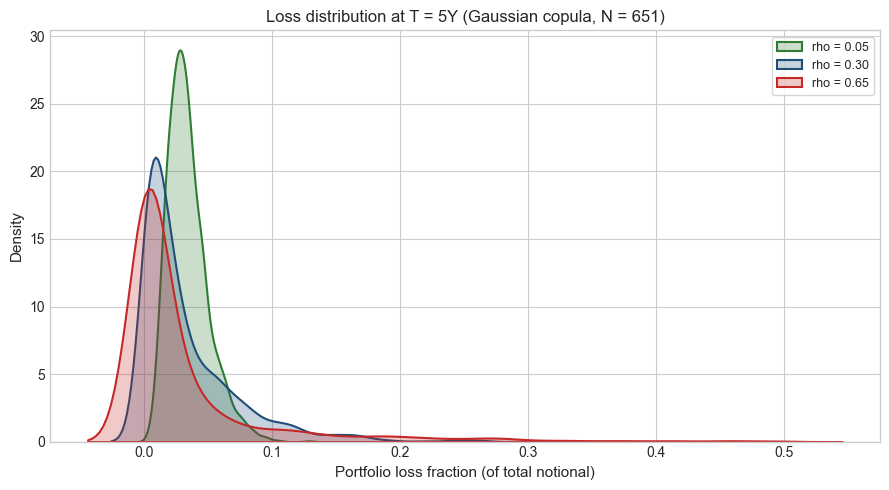

In [15]:

T_MAT = 5.0
N_SIM = 2_000
rho_low, rho_mid, rho_high = 0.05, 0.30, 0.65

L_low = simulate_loss_maturity(hazard_vec, T_MAT, rho_low, N_SIM, RNG)
L_mid = simulate_loss_maturity(hazard_vec, T_MAT, rho_mid, N_SIM, RNG)
L_high = simulate_loss_maturity(hazard_vec, T_MAT, rho_high, N_SIM, RNG)

fig, ax = plt.subplots()
for arr, lab, c in [
    (L_low, rf"rho = {rho_low:.2f}", "#2e7d32"),
    (L_mid, rf"rho = {rho_mid:.2f}", ACCENT),
    (L_high, rf"rho = {rho_high:.2f}", "#c62828"),
]:
    sns.kdeplot(arr, ax=ax, fill=True, alpha=0.25, linewidth=1.5, color=c, label=lab)
ax.set_xlabel("Portfolio loss fraction (of total notional)")
ax.set_ylabel("Density")
ax.set_title(f"Loss distribution at T = {T_MAT:.0f}Y (Gaussian copula, N = {N})")
ax.legend(frameon=True)
plt.tight_layout()
plt.show()


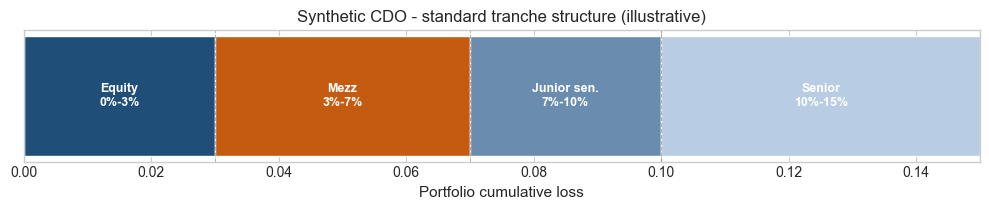

In [16]:
TRANCHES = [
    ("Equity", 0.00, 0.03),
    ("Mezz", 0.03, 0.07),
    ("Junior sen.", 0.07, 0.10),
    ("Senior", 0.10, 0.15),
]
attach = np.array([a for _, a, _ in TRANCHES])
detach = np.array([d for _, _, d in TRANCHES])
widths = detach - attach

fig, ax = plt.subplots(figsize=(10, 2.2))
left = attach
ax.barh(
    0,
    widths,
    left=left,
    height=0.35,
    align="center",
    color=[ACCENT, SECONDARY, "#6a8caf", "#b8cce4"],
    edgecolor="white",
    linewidth=1,
)
for name, a, d in TRANCHES:
    ax.text(
        (a + d) / 2,
        0,
        f"{name}\n{a:.0%}-{d:.0%}",
        ha="center",
        va="center",
        fontsize=9,
        color="white",
        fontweight="bold",
    )
ax.set_yticks([])
ax.set_xlim(0, 0.15)
ax.set_xlabel("Portfolio cumulative loss")
ax.set_title("Synthetic CDO - standard tranche structure (illustrative)")
for x in [0.03, 0.07, 0.10, 0.15]:
    ax.axvline(x, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.show()


## 8) Tính expected tranche loss tại từng payment date

Đây là output trung gian quan trọng nhất:

$$
ETL_k=\mathbb E[L^{A,D}(t_k)]
$$

Khi đã có $ETL_k$ cho mọi $t_k$, bài toán pricing gần như xong. Ma cho thấy valuation của tranche thực chất được rút về việc ước lượng $\mathbb E[L_k]$ tại các ngày coupon. ([U of T Computer Science](https://www.cs.toronto.edu/pub/reports/na/ma-07-phd.pdf))

Về mặt số, bạn có thể làm bước này bằng:

- Monte Carlo trên latent factor/default times
- recursion / bucketing / semi-analytic methods
- large-pool approximations nếu danh mục đồng nhất tương đối

Ma trình bày cả exact recursive method lẫn các xấp xỉ để tính phân phối pool loss hoặc trực tiếp expected tranche loss. ([U of T Computer Science](https://www.cs.toronto.edu/pub/reports/na/ma-07-phd.pdf))

In [17]:


def simulate_default_times_gaussian_copula(hazard_vec, rho, n_paths, rng):
    # Default times: exponential marginals + Gaussian copula.
    lam = np.asarray(hazard_vec, dtype=float)
    n = len(lam)
    m = rng.standard_normal((n_paths, 1))
    eps = rng.standard_normal((n_paths, n))
    y = np.sqrt(rho) * m + np.sqrt(1.0 - rho) * eps
    u = np.clip(norm.cdf(y), 1e-14, 1.0 - 1e-14)
    tau = -np.log(1.0 - u) / lam
    return tau


def portfolio_loss_from_tau(tau, t):
    return LGD * (tau <= t).mean(axis=1)


def etl_curve_schedule(hazard_vec, payment_dates, rho, attach, detach, n_paths=8000, rng=None):
    if rng is None:
        rng = np.random.default_rng(42)
    tau = simulate_default_times_gaussian_copula(hazard_vec, rho, n_paths, rng)
    etl = []
    for t in payment_dates:
        L = portfolio_loss_from_tau(tau, t)
        etl.append(tranche_loss(L, attach, detach).mean())
    return np.array(etl)


In [18]:
payment_dates = np.round(np.arange(0.25, T_MAT + 1e-9, 0.25), 8)
times_sched = np.concatenate([[0.0], payment_dates])
rho_price = 0.30

# Mot lan simulate tau cho tat ca tranche (cung the gioi rui ro)
rng_shared = np.random.default_rng(42)
tau_world = simulate_default_times_gaussian_copula(hazard_vec, rho_price, 10_000, rng_shared)


def etl_curve_from_tau(tau, payment_dates, attach, detach):
    etl = []
    for t in payment_dates:
        L = portfolio_loss_from_tau(tau, t)
        etl.append(tranche_loss(L, attach, detach).mean())
    return np.array(etl)

## 9) Định giá protection leg và premium leg

Sau khi có $ETL_k$, dùng đúng công thức định giá risk-neutral:

- **Protection leg PV** = discounted expected tranche loss increments
- **Premium leg PV** = running spread nhân với discounted expected outstanding tranche notional

Một dạng rời rạc chuẩn là:

$$
PV_{prot}\approx \sum_{k=1}^{n} d_k,\mathbb E[L_k-L_{k-1}]
$$

$$
PV_{prem}\approx s\sum_{k=1}^{n}\Delta_k, d_k,\mathbb E[(D-A)-L_k]
$$

trong đó $d_k$ là discount factor, $\Delta_k=t_k-t_{k-1},$ và s là running spread của tranche. Theo Ma, fair spread là spread làm cho present value expected loss bằng present value expected premium. ([U of T Computer Science](https://www.cs.toronto.edu/pub/reports/na/ma-07-phd.pdf))

Từ đó:

$$
s^*=\frac{\sum_{k=1}^{n} d_k\mathbb E[L_k-L_{k-1}]}{\sum_{k=1}^{n}\Delta_k, d_k\mathbb E[(D-A)-L_k]}
$$

Nếu coupon đã được ấn định sẵn bởi market convention, thì **upfront** của tranche chính là chênh lệch giữa protection leg và premium leg tính theo coupon đó. ([U of T Computer Science](https://www.cs.toronto.edu/pub/reports/na/ma-07-phd.pdf))

In [ ]:

def protection_leg(etl, times, df_fn):
    etl = np.asarray(etl, dtype=float)
    times = np.asarray(times, dtype=float)
    pl = 0.0
    for j in range(1, len(times)):
        pl += df_fn(times[j]) * (etl[j] - etl[j - 1])
    return pl


def premium_leg_annuity(etl, times, tranche_width, df_fn):
    etl = np.asarray(etl, dtype=float)
    times = np.asarray(times, dtype=float)
    ann = 0.0
    for j in range(len(times)):
        # outstanding tranche notional
        dt = times[j] - times[j - 1] if j > 0 else times[0]
        # ann += dt * df_fn(times[j]) * (tranche_width - etl[j])

        # midpoint/trapezoid
        outstanding_avg = tranche_width - 0.5 * (etl[j] + etl[j-1])
        ann += dt * df_fn(times[j]) * outstanding_avg
    return ann


def fair_running_spread(etl, times, attach, detach, df_fn):
    w = detach - attach
    pl = protection_leg(etl, times, df_fn)
    ann = premium_leg_annuity(etl, times, w, df_fn)
    return pl / ann if ann > 0 else np.nan


In [20]:

rows = []
etl_cache = {}
for label, a, d in TRANCHES:
    etl_path = etl_curve_from_tau(tau_world, payment_dates, a, d)
    etl_full = np.concatenate([[0.0], etl_path])
    s_fair = fair_running_spread(etl_full, times_sched, a, d, discount_factor)
    rows.append({
        "Tranche": label,
        "Attach": f"{a:.0%}",
        "Detach": f"{d:.0%}",
        "Width": f"{d-a:.0%}",
        "ETL@5Y": f"{etl_path[-1]:.4f}",
        "Fair spread (decimal)": s_fair,
        "Fair spread (bps)": s_fair * 10_000,
    })
    etl_cache[label] = etl_full

summary_df = pd.DataFrame(rows)
summary_df


,Tranche,Attach,Detach,Width,ETL@5Y,Fair spread (decimal),Fair spread (bps)
0,Equity,0%,3%,3%,0.0183,0.199200,1991.999334
1,Mezz,3%,7%,4%,0.0091,0.050371,503.708213
2,Junior sen.,7%,10%,3%,0.0030,0.020835,208.353312
3,Senior,10%,15%,5%,0.0022,0.008899,88.987783


## 10) Kiểm tra độ hợp lý theo capital structure

Sau khi có giá/fair spread cho mọi tranche, bạn phải sanity check:

- equity tranche phải nhạy mạnh với default sớm
- senior tranche phải nhạy mạnh với tail/default clustering
- correlation tăng thường làm **equity premium giảm** và **senior premium tăng**; mezzanine có thể phản ứng mơ hồ hơn
- expected loss phải tăng dần theo thời gian và theo thứ tự seniority hợp lý

ECB nhấn mạnh rằng correlation làm thay đổi shape của joint loss distribution; equity thường là “long correlation”, senior thường là “short correlation”, còn mezzanine có hiệu ứng không đơn điệu. ([European Central Bank](https://www.ecb.europa.eu/pub/pdf/fsr/art/ecb.fsrart200612_02.en.pdf))

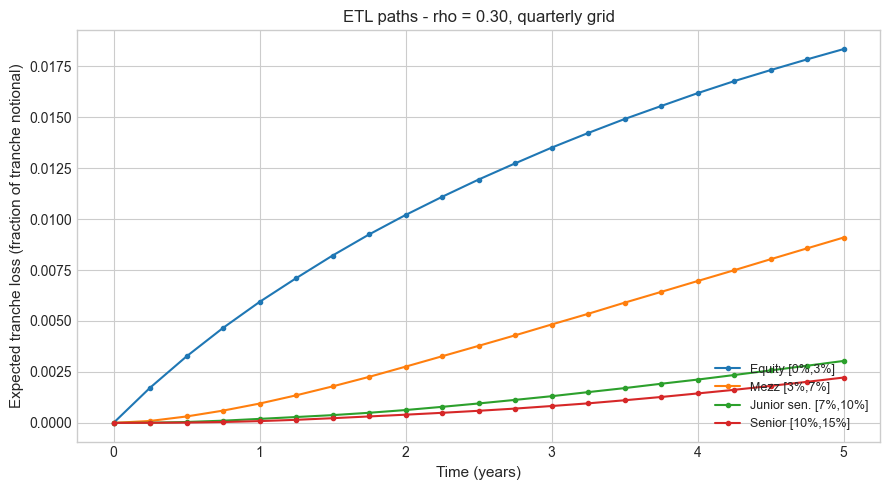

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
for label, a, d in TRANCHES:
    ax.plot(
        times_sched,
        etl_cache[label],
        marker="o",
        markersize=3,
        label=f"{label} [{a:.0%},{d:.0%}]",
    )
ax.set_xlabel("Time (years)")
ax.set_ylabel("Expected tranche loss (fraction of tranche notional)")
ax.set_title(f"ETL paths - rho = {rho_price:.2f}, quarterly grid")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


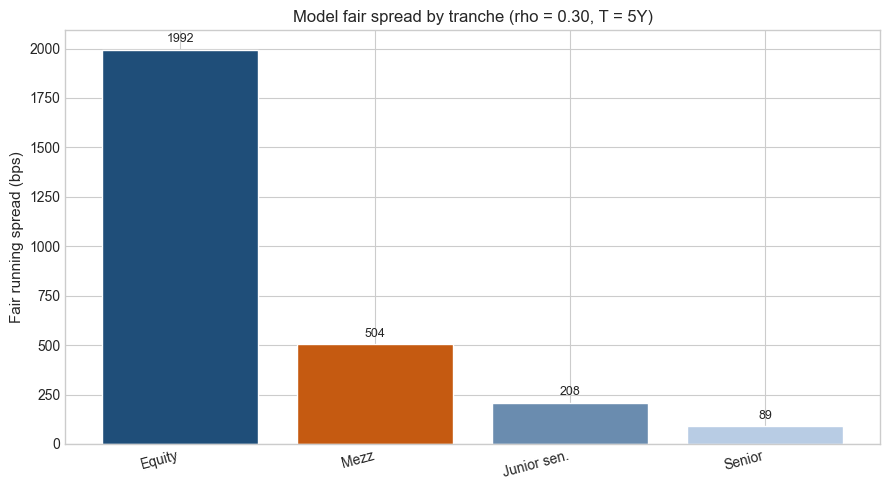

In [22]:
fig, ax = plt.subplots()
x = np.arange(len(TRANCHES))
bps = summary_df["Fair spread (bps)"].astype(float).values
ax.bar(x, bps, color=[ACCENT, SECONDARY, "#6a8caf", "#b8cce4"], edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels([t[0] for t in TRANCHES], rotation=15, ha="right")
ax.set_ylabel("Fair running spread (bps)")
ax.set_title(f"Model fair spread by tranche (rho = {rho_price:.2f}, T = {T_MAT:.0f}Y)")
for i, v in enumerate(bps):
    ax.text(i, v + max(bps) * 0.02, f"{v:.0f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()


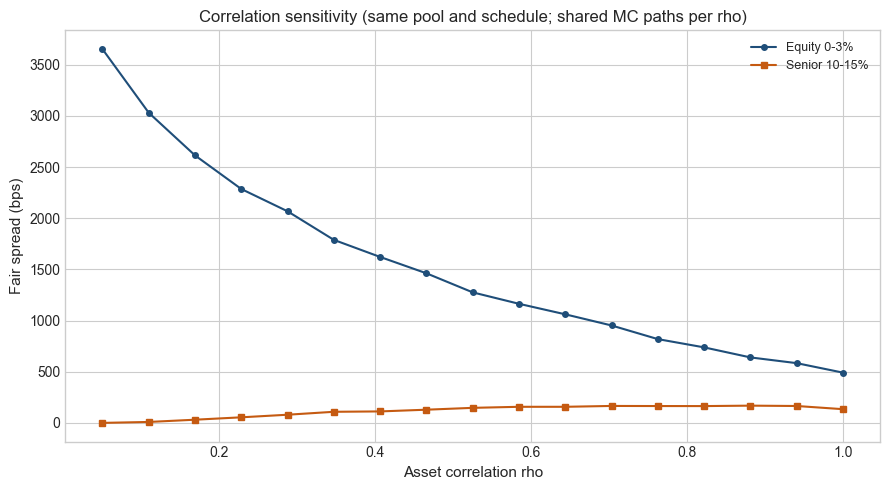

In [ ]:
rho_grid = np.linspace(0.05, 0.99, 17)
eq_spreads, sen_spreads = [], []
a0, d0 = TRANCHES[0][1], TRANCHES[0][2]
a3, d3 = TRANCHES[-1][1], TRANCHES[-1][2]
for k, rho in enumerate(rho_grid):
    rng = np.random.default_rng(10_000 + k)
    tau = simulate_default_times_gaussian_copula(hazard_vec, rho, 8000, rng)
    e0 = np.concatenate([[0.0], etl_curve_from_tau(tau, payment_dates, a0, d0)])
    e3 = np.concatenate([[0.0], etl_curve_from_tau(tau, payment_dates, a3, d3)])
    eq_spreads.append(fair_running_spread(e0, times_sched, a0, d0, discount_factor) * 10_000)
    sen_spreads.append(fair_running_spread(e3, times_sched, a3, d3, discount_factor) * 10_000)

fig, ax = plt.subplots()
ax.plot(rho_grid, eq_spreads, color=ACCENT, marker="o", markersize=4, label="Equity 0-3%")
ax.plot(rho_grid, sen_spreads, color=SECONDARY, marker="s", markersize=4, label="Senior 10-15%")
ax.set_xlabel("Asset correlation rho")
ax.set_ylabel("Fair spread (bps)")
ax.set_title("Correlation sensitivity (same pool and schedule; shared MC paths per rho)")
ax.legend()
plt.tight_layout()
plt.show()


## 11) Thêm counterparty risk và valuation adjustments nếu deal là OTC thực sự

Nếu bạn đang định giá để giao dịch OTC chứ không chỉ “clean price”, bạn không nên dừng ở fair tranche spread. Federal Reserve lưu ý rằng complex credit derivatives, trong đó có synthetic CDO tranches, có **counterparty risk** đáng kể và phần lớn sản phẩm loại này là **mark-to-model**, nên model risk cũng rất quan trọng. ([Federal Reserve](https://www.federalreserve.gov/pubs/feds/2007/200747/index.html))

Vì vậy ở bước cuối, desk thường cộng thêm hoặc ít nhất đánh giá riêng:

- CVA/DVA/FVA nếu có CSA/collateral/counterparty specifics
- jump-to-default exposure
- wrong-way risk
- liquidity/model reserves

## 12) Validation cuối cùng

Một pipeline định giá synthetic CDO tốt phải qua được 4 bài test:

1. **single-name consistency**: bootstrap CDS curve phải repricing lại CDS quotes
2. **tranche consistency**: model phải khớp index tranche quotes dùng để calibrate
3. **capital-structure sanity**: không có vi phạm hiển nhiên giữa các tranche
4. **stress tests**: spread widening, recovery giảm, correlation tăng, default clustering

Điểm này rất quan trọng vì Fed nhấn mạnh rủi ro mô hình trong tranched credit products đã từng bộc lộ rất rõ trên thị trường. ([Federal Reserve](https://www.federalreserve.gov/pubs/feds/2007/200747/index.html))